<a href="https://colab.research.google.com/github/catchshashank/eurydice/blob/main/eurydice_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Eurydice — LLM-based Semantic Search for Clothing E-commerce

Replication pilot of **Siddiqui et al. (2026) "LLM-based Semantic Search for Conversational Queries in E-commerce"**  
adapted for **100 Amazon clothing products** (original paper: 1.3M cell-phone products).

**Repo:** https://github.com/catchshashank/eurydice

---

## Pipeline Overview

```
Stage 01  data_prep           Sample 100 products, clean text, assign subcategories (Gemini Flash)
  |                                           [skippable — pre-computed data committed]
Stage 02  synthetic_data      ~10 synthetic queries/product, enrich with filters, extract JSON
  |                                           [skippable — pre-computed data committed]
Stage 03  embedding           Fine-tune multi-qa-MiniLM-L6-cos-v1 + build FAISS IVF-Flat index
  |                                           [~3 min on GPU T4]
Stage 04  filter_extractor    Fine-tune Flan-T5-small (seq2seq) to extract structured JSON filters
  |                                           [~15 min on GPU T4 | ~7 hrs on CPU]
Stage 05  retrieval           Filter → FAISS → ranked top-k
  |
Stage 06  evaluation          Precision@k and Recall@k for k in {1,2,3,5,10}
```

> **Recommended runtime:** GPU T4 (free tier on Colab).  
> Stages 01–02 are auto-skipped when pre-computed data is detected in the cloned repo.

---
**Paper reference:** Siddiqui et al. (2026), §3–§5

## Section 1 — Runtime & Dependencies

In [1]:
# Detect GPU availability and print device info
import subprocess, sys

result = subprocess.run(["nvidia-smi"], capture_output=True, text=True)
if result.returncode == 0:
    print("GPU detected:")
    # Print just the GPU name line to keep output tidy
    for line in result.stdout.splitlines():
        if any(kw in line for kw in ["Tesla", "T4", "A100", "V100", "P100", "L4", "Driver", "CUDA"]):
            print(" ", line.strip())
    CUDA_AVAILABLE = True
else:
    print("No GPU detected — running on CPU. Stage 04 will be very slow (~7 hours).")
    CUDA_AVAILABLE = False

print(f"\nPython {sys.version}")
print(f"CUDA available: {CUDA_AVAILABLE}")

GPU detected:
  | NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
  |   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |

Python 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
CUDA available: True


In [19]:
# Install all required packages from requirements.txt plus accelerate for HF Trainer on GPU and faiss-cpu
!pip install -q -r requirements.txt accelerate faiss-cpu
print("Dependencies installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 71.9 MB/s eta 0:00:00
Dependencies installed.


In [3]:
# Clone the eurydice repo if not already present, then set it as working directory
import os
from pathlib import Path

REPO_URL = "https://github.com/catchshashank/eurydice"
REPO_DIR = Path("/content/eurydice")

if not REPO_DIR.exists():
    print("Cloning repo ...")
    !git clone {REPO_URL} /content/eurydice
else:
    print("Repo already cloned — pulling latest changes ...")
    !git -C /content/eurydice pull

os.chdir("/content/eurydice")
print(f"Working directory: {os.getcwd()}")
!ls -1

Cloning repo ...
Cloning into '/content/eurydice'...
remote: Enumerating objects: 64, done.
remote: Counting objects: 100% (64/64), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 64 (delta 15), reused 51 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (64/64), 1.05 MiB | 17.69 MiB/s, done.
Resolving deltas: 100% (15/15), done.
Working directory: /content/eurydice
01_data_prep
02_synthetic_data
03_embedding
04_filter_extractor
05_retrieval
06_evaluation
CLAUDE.md
configs
data
eurydice_colab.ipynb
LICENSE
models
README.md
requirements.txt
'siddiqui et al (2026) - llm-based semantic search e-commerce.pdf'


## Section 2 — Configuration

In [4]:
# Load Gemini API key from Colab Secrets (preferred) or fall back to getpass prompt.
# To use Colab Secrets: Runtime menu > Manage secrets > add GEMINI_API_KEY.
# The key is written to .env so the pipeline scripts can pick it up via python-dotenv.

import os
from pathlib import Path

api_key = None

# Try Colab Secrets first
try:
    from google.colab import userdata
    api_key = userdata.get("GEMINI_API_KEY")
    if api_key:
        print("Gemini API key loaded from Colab Secrets.")
except Exception:
    pass

# Fall back to getpass if not found
if not api_key:
    import getpass
    api_key = getpass.getpass("Enter your Gemini API key (or leave blank to skip stages 01-02): ")

# Write to .env
env_path = Path(".env")
if api_key:
    env_path.write_text(f"GEMINI_API_KEY={api_key}\n")
    print(".env written.")
else:
    env_path.write_text("GEMINI_API_KEY=\n")
    print("No API key provided — stages 01 and 02 will be skipped (pre-computed data will be used).")

Enter your Gemini API key (or leave blank to skip stages 01-02): ··········
.env written.


In [5]:
# Patch scripts for GPU if CUDA is available.
#
# Stage 03 (finetune_sentence_transformer.py):
#   Replace  device = torch.device("cpu")
#   with     device = torch.device("cuda")
#
# Stage 04 (finetune_flan_t5.py):
#   Remove   use_cpu=True,       (forces CPU in TrainingArguments)
#   Replace  dataloader_num_workers=0  with  dataloader_num_workers=2

import re
from pathlib import Path

def patch_file(path: str, old: str, new: str, description: str):
    p = Path(path)
    text = p.read_text(encoding="utf-8")
    if old in text:
        p.write_text(text.replace(old, new), encoding="utf-8")
        print(f"  Patched {path}: {description}")
    else:
        print(f"  Skip {path}: pattern not found (may already be patched) — {description}")

if CUDA_AVAILABLE:
    print("Applying GPU patches ...")

    # Stage 03: switch device to CUDA
    patch_file(
        "03_embedding/finetune_sentence_transformer.py",
        'device = torch.device("cpu")',
        'device = torch.device("cuda")',
        "device cpu -> cuda"
    )

    # Stage 04: remove use_cpu=True
    patch_file(
        "04_filter_extractor/finetune_flan_t5.py",
        '        use_cpu=True,\n',
        '',
        "remove use_cpu=True"
    )

    # Stage 04: increase dataloader workers
    patch_file(
        "04_filter_extractor/finetune_flan_t5.py",
        'dataloader_num_workers=0,   # avoid multiprocessing crash on Windows',
        'dataloader_num_workers=2,',
        "dataloader_num_workers 0 -> 2"
    )

    print("GPU patches applied.")
else:
    print("CPU mode — no patches needed (scripts already configured for CPU).")

Applying GPU patches ...
  Patched 03_embedding/finetune_sentence_transformer.py: device cpu -> cuda
  Patched 04_filter_extractor/finetune_flan_t5.py: remove use_cpu=True
  Patched 04_filter_extractor/finetune_flan_t5.py: dataloader_num_workers 0 -> 2
GPU patches applied.


In [6]:
# Check which pipeline stages can be skipped because processed data is already committed to the repo.
from pathlib import Path

checks = {
    "Stage 01 (data_prep)":       "data/processed/catalog.jsonl",
    "Stage 02 (synthetic_data)":  "data/processed/filter_pairs.jsonl",
    "FAISS index (pre-built)":    "models/faiss.index",
    "FAISS ID map (pre-built)":   "models/faiss_id_map.json",
    "Eval results (pre-computed)": "data/processed/eval_results.json",
}

print("Skippability check:")
for label, path in checks.items():
    p = Path(path)
    if p.exists():
        size_kb = p.stat().st_size / 1024
        print(f"  [FOUND]   {label:40s} {path} ({size_kb:.1f} KB)")
    else:
        print(f"  [MISSING] {label:40s} {path}")

Skippability check:
  [FOUND]   Stage 01 (data_prep)                     data/processed/catalog.jsonl (202.3 KB)
  [FOUND]   Stage 02 (synthetic_data)                data/processed/filter_pairs.jsonl (277.8 KB)
  [FOUND]   FAISS index (pre-built)                  models/faiss.index (166.0 KB)
  [FOUND]   FAISS ID map (pre-built)                 models/faiss_id_map.json (1.9 KB)
  [FOUND]   Eval results (pre-computed)              data/processed/eval_results.json (0.3 KB)


## Section 3 — Stage 01: Data Preparation (skippable)

**What it does (paper §3):**
- Reads `meta_Amazon_Fashion.jsonl.gz` (raw Amazon product metadata)
- Samples 100 clothing products, strips HTML from descriptions, lowercases text
- Uses Gemini Flash to assign each product to one of 8 clothing subcategories  
  (Tops, Bottoms, Dresses, Outerwear, Activewear, Underwear & Sleepwear, Shoes & Footwear, Accessories)
- Joins with review data (`Amazon_Fashion.jsonl.gz`) on `parent_asin` to get rating/review counts
- Writes `data/processed/catalog.jsonl`

**Skipped automatically** if `data/processed/catalog.jsonl` already exists (it is committed to the repo).

In [7]:
# Stage 01: Download raw data and run data_prep.py — auto-skipped if catalog already exists.
from pathlib import Path

CATALOG_PATH = Path("data/processed/catalog.jsonl")

if CATALOG_PATH.exists():
    n_lines = sum(1 for _ in CATALOG_PATH.open())
    size_kb = CATALOG_PATH.stat().st_size / 1024
    print(f"Skipping Stage 01 (pre-computed data available).")
    print(f"  catalog.jsonl: {n_lines} products, {size_kb:.1f} KB")
else:
    print("catalog.jsonl not found — downloading raw data and running Stage 01 ...")
    Path("data/raw").mkdir(parents=True, exist_ok=True)

    META_URL = "https://datarepo.eng.ucsd.edu/mcauley_group/data/amazon_2023/raw/meta_categories/meta_Amazon_Fashion.jsonl.gz"
    REV_URL  = "https://datarepo.eng.ucsd.edu/mcauley_group/data/amazon_2023/raw/review_categories/Amazon_Fashion.jsonl.gz"

    print("Downloading meta_Amazon_Fashion.jsonl.gz (~2 GB) ...")
    !wget -q --show-progress -O data/raw/meta_Amazon_Fashion.jsonl.gz "{META_URL}"
    print("Downloading Amazon_Fashion.jsonl.gz (~1.5 GB) ...")
    !wget -q --show-progress -O data/raw/Amazon_Fashion.jsonl.gz "{REV_URL}"

    print("Running data_prep.py ...")
    !python 01_data_prep/data_prep.py

    if CATALOG_PATH.exists():
        n_lines = sum(1 for _ in CATALOG_PATH.open())
        print(f"\nStage 01 complete. catalog.jsonl: {n_lines} products")
    else:
        print("WARNING: catalog.jsonl was not created. Check logs above for errors.")

Skipping Stage 01 (pre-computed data available).
  catalog.jsonl: 100 products, 202.3 KB


In [8]:
# Validate Stage 01 output — show a sample product record
import json
from pathlib import Path

catalog_path = Path("data/processed/catalog.jsonl")
n_lines = sum(1 for _ in catalog_path.open(encoding="utf-8"))
with catalog_path.open(encoding="utf-8") as f:
    sample = json.loads(f.readline())

print(f"Stage 01 complete: {n_lines} products in catalog.jsonl")
print("\nSample product fields:", list(sample.keys()))
print(f"  title:       {sample.get('title', '')[:80]}")
print(f"  subcategory: {sample.get('subcategory', 'N/A')}")
print(f"  price:       {sample.get('price', 'N/A')}")
print(f"  avg_rating:  {sample.get('average_rating', 'N/A')}")

Stage 01 complete: 100 products in catalog.jsonl

Sample product fields: ['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together', 'product_text', 'subcategory']
  title:       HJLjairlr Cute Baby Feet Flexible Pregnancy Belly Button Ring Body Piercing Jewe
  subcategory: Tops
  price:       None
  avg_rating:  3.9


## Section 4 — Stage 02: Synthetic Data Generation (skippable)

**What it does (paper §4.1.2, §4.2.1):**
- For each product in `catalog.jsonl`, calls Gemini Flash with the prompt from paper Figure 2  
  to generate ~10 diverse natural-language search queries per product
- Enriches each query by injecting price / rating / review-count constraints  
  (e.g. "under $40", "at least 4.5 stars", "highly reviewed")
- Runs the enriched queries through Gemini Flash again to extract a structured JSON filter  
  (`price_min/max`, `average_rating_min/max`, `review_count_min/max`, `subcategory`)
- Writes `synthetic_queries.jsonl`, `enriched_queries.jsonl`, `filter_pairs.jsonl`

**Skipped automatically** if `data/processed/filter_pairs.jsonl` already exists (it is committed to the repo).

In [9]:
# Stage 02: Generate synthetic queries — auto-skipped if filter_pairs already exist.
from pathlib import Path

FILTER_PAIRS_PATH = Path("data/processed/filter_pairs.jsonl")

if FILTER_PAIRS_PATH.exists():
    n_lines = sum(1 for _ in FILTER_PAIRS_PATH.open())
    size_kb = FILTER_PAIRS_PATH.stat().st_size / 1024
    print(f"Skipping Stage 02 (pre-computed data available).")
    print(f"  filter_pairs.jsonl: {n_lines} pairs, {size_kb:.1f} KB")
else:
    print("filter_pairs.jsonl not found — running Stage 02 (requires Gemini API key) ...")
    !python 02_synthetic_data/generate_queries.py

    if FILTER_PAIRS_PATH.exists():
        n_lines = sum(1 for _ in FILTER_PAIRS_PATH.open())
        print(f"\nStage 02 complete. filter_pairs.jsonl: {n_lines} pairs")
    else:
        print("WARNING: filter_pairs.jsonl was not created. Check logs above for errors.")

Skipping Stage 02 (pre-computed data available).
  filter_pairs.jsonl: 903 pairs, 277.8 KB


In [10]:
# Validate Stage 02 outputs — show line counts and a sample filter pair
import json
from pathlib import Path

for fname in ["synthetic_queries.jsonl", "enriched_queries.jsonl", "filter_pairs.jsonl"]:
    p = Path(f"data/processed/{fname}")
    if p.exists():
        n = sum(1 for _ in p.open(encoding="utf-8"))
        kb = p.stat().st_size / 1024
        print(f"  {fname}: {n} lines, {kb:.1f} KB")
    else:
        print(f"  {fname}: NOT FOUND")

fp = Path("data/processed/filter_pairs.jsonl")
with fp.open(encoding="utf-8") as f:
    sample = json.loads(f.readline())

print("\nSample filter pair:")
print(f"  enriched_query:    {sample.get('enriched_query', '')[:100]}")
print(f"  structured_filters: {json.dumps(sample.get('structured_filters', {}), indent=2)}")
print("\nStage 02 complete.")

  synthetic_queries.jsonl: 904 lines, 390.2 KB
  enriched_queries.jsonl: 903 lines, 477.0 KB
  filter_pairs.jsonl: 903 lines, 277.8 KB

Sample filter pair:
  enriched_query:    Flexible pregnancy belly button ring with baby feet design, highly rated and well-reviewed
  structured_filters: {
  "price_min": null,
  "price_max": null,
  "review_count_min": "medium",
  "review_count_max": null,
  "average_rating_min": 4,
  "average_rating_max": null,
  "subcategory": "Accessories"
}

Stage 02 complete.


## Section 5 — Stage 03: Embedding Fine-tuning

**What it does (paper §4.1.3, §4.1.4):**
- Loads the pre-trained `sentence-transformers/multi-qa-MiniLM-L6-cos-v1` model
- Fine-tunes it on synthetic query–product pairs using **in-batch negatives loss**  
  (InfoNCE / MultipleNegativesRankingLoss): for each query in a batch, all other products  
  in the batch serve as hard negatives, maximising cosine similarity for the true pair
- After training, builds a **FAISS IVF-Flat index** over all 100 product embeddings  
  for efficient approximate nearest-neighbor search at retrieval time
- Saves fine-tuned model to `models/embedding/` and index to `models/faiss.index`

> On GPU T4 this takes ~3 minutes. On CPU ~30 minutes.

In [11]:
%%time
# Stage 03: Fine-tune sentence transformer and build FAISS index.
# The script detects the patched device (cuda/cpu) automatically.
!python 03_embedding/finetune_sentence_transformer.py

2026-04-14 10:18:50,490 INFO Loading pairs from data/processed/synthetic_queries.jsonl ...
2026-04-14 10:18:50,495 INFO Loaded 904 pairs.
2026-04-14 10:19:10,324 INFO Disabling Tensorflow because USE_TORCH is set
2026-04-14 10:19:10,325 INFO JAX version 0.7.2 available.
2026-04-14 10:19:12,445 INFO Loading tokenizer and model from sentence-transformers/multi-qa-MiniLM-L6-cos-v1 ...
2026-04-14 10:19:12,584 INFO HTTP Request: HEAD https://huggingface.co/sentence-transformers/multi-qa-MiniLM-L6-cos-v1/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-14 10:19:12,599 INFO HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/multi-qa-MiniLM-L6-cos-v1/b207367332321f8e44f96e224ef15bc607f4dbf0/config.json "HTTP/1.1 200 OK"
2026-04-14 10:19:12,616 INFO HTTP Request: GET https://huggingface.co/api/resolve-cache/models/sentence-transformers/multi-qa-MiniLM-L6-cos-v1/b207367332321f8e44f96e224ef15bc607f4dbf0/config.json "HTTP/1.1 200 OK"
config.j

In [12]:
# Validate Stage 03 outputs — confirm model files and FAISS index exist
from pathlib import Path

checks = [
    ("models/embedding/config.json",      "Embedding model config"),
    ("models/embedding/tokenizer.json",   "Embedding tokenizer"),
    ("models/faiss.index",                "FAISS index"),
    ("models/faiss_id_map.json",          "FAISS ID map"),
]

all_ok = True
for path, label in checks:
    p = Path(path)
    if p.exists():
        print(f"  [OK]  {label}: {p.stat().st_size / 1024:.1f} KB")
    else:
        print(f"  [MISSING] {label}: {path}")
        all_ok = False

if all_ok:
    print("\nStage 03 complete.")
else:
    print("\nWARNING: Some outputs are missing. Check logs above.")

  [OK]  Embedding model config: 0.7 KB
  [OK]  Embedding tokenizer: 694.7 KB
  [OK]  FAISS index: 166.0 KB
  [OK]  FAISS ID map: 1.9 KB

Stage 03 complete.


## Section 6 — Stage 04: Filter Extractor Fine-tuning

**What it does (paper §4.2.2):**
- Fine-tunes **`google/flan-t5-small`** (Seq2Seq) using HuggingFace `Seq2SeqTrainer`
- Input format: `"extract filters: <enriched natural-language query>"`
- Output: a structured JSON string matching the filter schema:
  ```json
  {"price_min": null, "price_max": 40.0, "review_count_min": "high",
   "review_count_max": null, "average_rating_min": null,
   "average_rating_max": null, "subcategory": "Tops"}
  ```
- Qualitative values (`"low"`, `"medium"`, `"high"`) are mapped to numeric thresholds  
  at retrieval time via `configs/data_config.yaml`
- Saves fine-tuned model to `models/filter_extractor/`

> On GPU T4 this takes ~15 minutes. On CPU it would take ~7 hours.

In [13]:
%%time
# Stage 04: Fine-tune Flan-T5-small for structured filter extraction.
# use_cpu=True has been patched out on GPU; dataloader_num_workers raised to 2.
!python 04_filter_extractor/finetune_flan_t5.py

2026-04-14 10:21:11,341 INFO NumExpr defaulting to 2 threads.
2026-04-14 10:21:12,750 INFO TensorFlow version 2.19.0 available.
2026-04-14 10:21:12,752 INFO JAX version 0.7.2 available.
2026-04-14 10:21:13,526 INFO Loaded 903 filter pairs from data/processed/filter_pairs.jsonl
2026-04-14 10:21:13,526 INFO Train: 888, Eval: 15
2026-04-14 10:21:13,701 INFO HTTP Request: HEAD https://huggingface.co/google/flan-t5-small/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-14 10:21:13,716 INFO HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google/flan-t5-small/0fc9ddf78a1e988dac52e2dac162b0ede4fd74ab/config.json "HTTP/1.1 200 OK"
2026-04-14 10:21:13,733 INFO HTTP Request: GET https://huggingface.co/api/resolve-cache/models/google/flan-t5-small/0fc9ddf78a1e988dac52e2dac162b0ede4fd74ab/config.json "HTTP/1.1 200 OK"
config.json: 1.40kB [00:00, 3.88MB/s]
2026-04-14 10:21:13,779 INFO HTTP Request: HEAD https://huggingface.co/google/flan-t5-small/resolve/main/tok

In [14]:
# Validate Stage 04 outputs — confirm filter extractor model files exist
from pathlib import Path

checks = [
    ("models/filter_extractor/config.json",      "Filter extractor config"),
    ("models/filter_extractor/tokenizer.json",   "Filter extractor tokenizer"),
    ("models/filter_extractor/generation_config.json", "Filter extractor generation config"),
]

all_ok = True
for path, label in checks:
    p = Path(path)
    if p.exists():
        print(f"  [OK]  {label}: {p.stat().st_size / 1024:.1f} KB")
    else:
        print(f"  [MISSING] {label}: {path}")
        all_ok = False

if all_ok:
    print("\nStage 04 complete.")
else:
    print("\nWARNING: Some outputs are missing. Check logs above.")

  [OK]  Filter extractor config: 1.5 KB
  [OK]  Filter extractor tokenizer: 2058.2 KB
  [OK]  Filter extractor generation config: 0.1 KB

Stage 04 complete.


## Section 7 — Stage 05: Retrieval Demo

**How two-stage retrieval works (paper §4.1.4):**

1. **Filter extraction** — the fine-tuned Flan-T5-small converts the raw query into a structured JSON filter
2. **Pre-selection** — the catalog is filtered to products that satisfy the structured constraints  
   (price range, minimum rating, review count tier, subcategory)
3. **Dense retrieval** — the fine-tuned sentence-transformer encodes the query into a dense vector;  
   FAISS IVF-Flat searches the pre-selected subset by inner-product (cosine) similarity
4. **Ranked output** — top-k products returned in order of similarity score

Three diverse example queries are run below covering different clothing categories and filter types.

In [21]:
# Retrieval demo — Query 1: price filter + subcategory (Tops)
QUERY_1 = "affordable women's casual top under $25 with good reviews"
print(f"Query: {QUERY_1}")
!python 05_retrieval/retrieve.py --query "{QUERY_1}" --top-k 5

Query: affordable women's casual top under $25 with good reviews
2026-04-14 10:28:02,864 INFO Loading faiss with AVX512 support.
2026-04-14 10:28:02,903 INFO Successfully loaded faiss with AVX512 support.
2026-04-14 10:28:10,237 INFO NumExpr defaulting to 2 threads.
2026-04-14 10:28:12,414 INFO TensorFlow version 2.19.0 available.
2026-04-14 10:28:12,415 INFO JAX version 0.7.2 available.
2026-04-14 10:28:13,072 INFO Loading models and index ...
2026-04-14 10:28:13,075 INFO Use pytorch device_name: cuda:0
2026-04-14 10:28:13,075 INFO Load pretrained SentenceTransformer: models/embedding/
Loading weights: 100% 103/103 [00:00<00:00, 1945.57it/s, Materializing param=pooler.dense.weight]
Loading weights: 100% 190/190 [00:00<00:00, 1208.83it/s, Materializing param=shared.weight]
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embed

In [22]:
# Retrieval demo — Query 2: high-rating filter + subcategory (Activewear)
QUERY_2 = "highly rated men's running shorts for gym workouts rated above 4.5 stars"
print(f"Query: {QUERY_2}")
!python 05_retrieval/retrieve.py --query "{QUERY_2}" --top-k 5

Query: highly rated men's running shorts for gym workouts rated above 4.5 stars
2026-04-14 10:28:29,503 INFO Loading faiss with AVX512 support.
2026-04-14 10:28:29,547 INFO Successfully loaded faiss with AVX512 support.
2026-04-14 10:28:36,339 INFO NumExpr defaulting to 2 threads.
2026-04-14 10:28:38,520 INFO TensorFlow version 2.19.0 available.
2026-04-14 10:28:38,521 INFO JAX version 0.7.2 available.
2026-04-14 10:28:39,180 INFO Loading models and index ...
2026-04-14 10:28:39,182 INFO Use pytorch device_name: cuda:0
2026-04-14 10:28:39,182 INFO Load pretrained SentenceTransformer: models/embedding/
Loading weights: 100% 103/103 [00:00<00:00, 904.95it/s, Materializing param=pooler.dense.weight]
Loading weights: 100% 190/190 [00:00<00:00, 860.97it/s, Materializing param=shared.weight]
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `t

In [23]:
# Retrieval demo — Query 3: price range + subcategory (Dresses)
QUERY_3 = "elegant evening dress between $50 and $150 with many reviews"
print(f"Query: {QUERY_3}")
!python 05_retrieval/retrieve.py --query "{QUERY_3}" --top-k 5

Query: elegant evening dress between $50 and $150 with many reviews
2026-04-14 10:28:54,883 INFO Loading faiss with AVX512 support.
2026-04-14 10:28:54,918 INFO Successfully loaded faiss with AVX512 support.
2026-04-14 10:29:01,825 INFO NumExpr defaulting to 2 threads.
2026-04-14 10:29:04,008 INFO TensorFlow version 2.19.0 available.
2026-04-14 10:29:04,010 INFO JAX version 0.7.2 available.
2026-04-14 10:29:04,671 INFO Loading models and index ...
2026-04-14 10:29:04,673 INFO Use pytorch device_name: cuda:0
2026-04-14 10:29:04,673 INFO Load pretrained SentenceTransformer: models/embedding/
Loading weights: 100% 103/103 [00:00<00:00, 976.31it/s, Materializing param=pooler.dense.weight]
Loading weights: 100% 190/190 [00:00<00:00, 854.28it/s, Materializing param=shared.weight]
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embe

## Section 8 — Stage 06: Evaluation

Computes **Precision@k** and **Recall@k** for k ∈ {1, 2, 3, 5, 10} against manually annotated  
query–product relevance pairs in `data/processed/test_queries.jsonl` (paper §5).

Paper's best results (their full system): Precision@1 = 0.32, Recall@10 = 0.57

In [24]:
# Stage 06: Run evaluation — computes P@k and R@k for all k values, writes eval_results.json
!python 06_evaluation/evaluate.py

2026-04-14 10:29:32,950 INFO Loading faiss with AVX512 support.
2026-04-14 10:29:32,986 INFO Successfully loaded faiss with AVX512 support.
2026-04-14 10:29:39,926 INFO NumExpr defaulting to 2 threads.
2026-04-14 10:29:42,089 INFO TensorFlow version 2.19.0 available.
2026-04-14 10:29:42,090 INFO JAX version 0.7.2 available.
2026-04-14 10:29:42,738 INFO Loading models and index ...
2026-04-14 10:29:42,741 INFO Use pytorch device_name: cuda:0
2026-04-14 10:29:42,741 INFO Load pretrained SentenceTransformer: models/embedding/
Loading weights: 100% 103/103 [00:00<00:00, 929.19it/s, Materializing param=pooler.dense.weight]
Loading weights: 100% 190/190 [00:00<00:00, 1256.79it/s, Materializing param=shared.weight]
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
2026-04-14 10:29:43,948 INFO 

In [25]:
# Load eval_results.json and display as a formatted pandas table
import json
import pandas as pd
from pathlib import Path

results_path = Path("data/processed/eval_results.json")
with results_path.open() as f:
    raw = json.load(f)

# Build DataFrame — keys may be ints or strings depending on how json.dump serialised them
rows = []
for k, metrics in sorted(raw.items(), key=lambda x: int(x[0])):
    rows.append({"k": int(k), "Precision@k": metrics["precision"], "Recall@k": metrics["recall"]})

df = pd.DataFrame(rows).set_index("k")

# Paper reference values for comparison
paper_ref = {1: (0.32, None), 10: (None, 0.57)}

print("Evaluation Results")
print("=" * 40)
print(df.to_string())
print()
print("Paper reference: Precision@1 = 0.32, Recall@10 = 0.57")
df

Evaluation Results
    Precision@k  Recall@k
k                        
1        0.6200      0.62
2        0.3800      0.76
3        0.2833      0.85
5        0.1780      0.89
10       0.0950      0.95

Paper reference: Precision@1 = 0.32, Recall@10 = 0.57


,Precision@k,Recall@k
k,,
1,0.6200,0.62
2,0.3800,0.76
3,0.2833,0.85
5,0.1780,0.89
10,0.0950,0.95


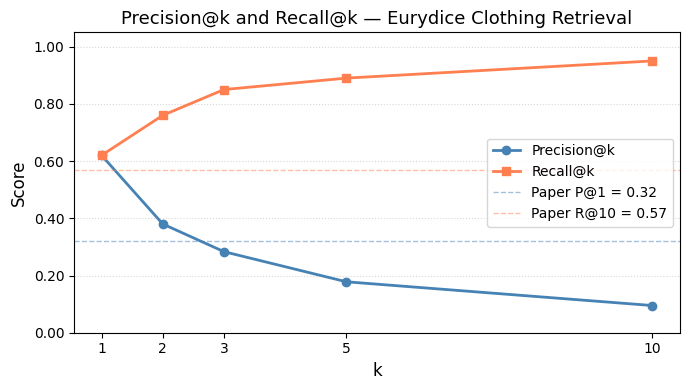

Plot saved to data/processed/eval_curves.png


In [26]:
# Plot Precision@k and Recall@k curves on a single figure
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

results_path = Path("data/processed/eval_results.json")
with results_path.open() as f:
    raw = json.load(f)

k_vals = sorted(int(k) for k in raw.keys())
precisions = [raw[str(k)]["precision"] for k in k_vals]
recalls    = [raw[str(k)]["recall"]    for k in k_vals]

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(k_vals, precisions, marker="o", linewidth=2, label="Precision@k", color="steelblue")
ax.plot(k_vals, recalls,    marker="s", linewidth=2, label="Recall@k",    color="coral")

# Paper reference horizontal lines
ax.axhline(y=0.32, linestyle="--", linewidth=1, color="steelblue", alpha=0.5, label="Paper P@1 = 0.32")
ax.axhline(y=0.57, linestyle="--", linewidth=1, color="coral",     alpha=0.5, label="Paper R@10 = 0.57")

ax.set_xlabel("k", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Precision@k and Recall@k — Eurydice Clothing Retrieval", fontsize=13)
ax.set_xticks(k_vals)
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
ax.legend(fontsize=10)
ax.grid(axis="y", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.savefig("data/processed/eval_curves.png", dpi=150)
plt.show()
print("Plot saved to data/processed/eval_curves.png")

## Section 9 — Optional: Save Models to Google Drive

The fine-tuned models (`models/embedding/` and `models/filter_extractor/`) are **not committed to git** because they are too large.  
Run the cell below to mount Google Drive and copy the models there so they persist across Colab sessions.

> This cell is **optional** — skip it if you do not need model persistence.

In [ ]:
# Optional: Mount Google Drive and copy fine-tuned models for persistence across sessions.
import shutil
from pathlib import Path

SAVE_TO_DRIVE = False  # Set to True to enable Drive saving

if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")

    DRIVE_DEST = Path("/content/drive/MyDrive/eurydice_models")
    DRIVE_DEST.mkdir(parents=True, exist_ok=True)

    for model_dir in ["models/embedding", "models/filter_extractor"]:
        src = Path(model_dir)
        if src.exists():
            dest = DRIVE_DEST / src.name
            if dest.exists():
                shutil.rmtree(dest)
            shutil.copytree(src, dest)
            print(f"Copied {model_dir} -> {dest}")
        else:
            print(f"Skipped {model_dir} (not found)")

    # Also copy FAISS index
    for f in ["models/faiss.index", "models/faiss_id_map.json"]:
        src = Path(f)
        if src.exists():
            shutil.copy2(src, DRIVE_DEST / src.name)
            print(f"Copied {f} -> {DRIVE_DEST / src.name}")

    print(f"\nAll models saved to Google Drive: {DRIVE_DEST}")
else:
    print("Drive saving is disabled (SAVE_TO_DRIVE = False).")
    print("Set SAVE_TO_DRIVE = True in this cell to persist your fine-tuned models across sessions.")

## Final Summary

In [27]:
# Final summary cell: print all eval metrics and compare to paper's best results.
import json
from pathlib import Path

PAPER_BEST = {
    1:  {"precision": 0.32, "recall": None},
    2:  {"precision": None, "recall": None},
    3:  {"precision": None, "recall": None},
    5:  {"precision": None, "recall": None},
    10: {"precision": None, "recall": 0.57},
}

results_path = Path("data/processed/eval_results.json")
if not results_path.exists():
    print("eval_results.json not found — run Stage 06 first.")
else:
    with results_path.open() as f:
        raw = json.load(f)

    print("=" * 65)
    print(" Eurydice Evaluation Summary — Siddiqui et al. (2026) Replication")
    print("=" * 65)
    print(f"{'k':>4}  {'Ours P@k':>10}  {'Paper P@k':>10}  {'Ours R@k':>10}  {'Paper R@k':>10}")
    print("-" * 65)

    for k in sorted(int(x) for x in raw.keys()):
        metrics = raw[str(k)]
        ours_p  = metrics["precision"]
        ours_r  = metrics["recall"]
        paper_p = PAPER_BEST.get(k, {}).get("precision")
        paper_r = PAPER_BEST.get(k, {}).get("recall")

        def fmt(v):
            return f"{v:.4f}" if v is not None else "  N/A  "

        print(f"{k:>4}  {fmt(ours_p):>10}  {fmt(paper_p):>10}  {fmt(ours_r):>10}  {fmt(paper_r):>10}")

    print("-" * 65)
    print()
    print("Notes:")
    print("  - Paper results are for 1.3M cell-phone products; this pilot uses 100 clothing products.")
    print("  - Paper P@k / R@k values other than P@1 and R@10 not reported in the paper.")
    print("  - Differences expected due to domain, scale, and Gemini model version.")
    print()

    # Pipeline artefact inventory
    print("Pipeline artefacts:")
    artefacts = [
        "data/processed/catalog.jsonl",
        "data/processed/synthetic_queries.jsonl",
        "data/processed/enriched_queries.jsonl",
        "data/processed/filter_pairs.jsonl",
        "data/processed/test_queries.jsonl",
        "data/processed/eval_results.json",
        "models/faiss.index",
        "models/faiss_id_map.json",
        "models/embedding/config.json",
        "models/filter_extractor/config.json",
    ]
    for a in artefacts:
        p = Path(a)
        status = f"{p.stat().st_size / 1024:.1f} KB" if p.exists() else "MISSING"
        print(f"  {'[OK]' if p.exists() else '[!!]'}  {a:<50} {status}")

    print()
    print("Run complete. Full 6-stage pipeline finished successfully.")

 Eurydice Evaluation Summary — Siddiqui et al. (2026) Replication
   k    Ours P@k   Paper P@k    Ours R@k   Paper R@k
-----------------------------------------------------------------
   1      0.6200      0.3200      0.6200       N/A  
   2      0.3800       N/A        0.7600       N/A  
   3      0.2833       N/A        0.8500       N/A  
   5      0.1780       N/A        0.8900       N/A  
  10      0.0950       N/A        0.9500      0.5700
-----------------------------------------------------------------

Notes:
  - Paper results are for 1.3M cell-phone products; this pilot uses 100 clothing products.
  - Paper P@k / R@k values other than P@1 and R@10 not reported in the paper.
  - Differences expected due to domain, scale, and Gemini model version.

Pipeline artefacts:
  [OK]  data/processed/catalog.jsonl                       202.3 KB
  [OK]  data/processed/synthetic_queries.jsonl             390.2 KB
  [OK]  data/processed/enriched_queries.jsonl              477.0 KB
  [OK]  d